# RQ2: Which security practices are most strongly associated with security outcomes?

Note:  Portions of this notebook were assisted with Claude.   An initial analysis was performed forming variables, creating models and initial analysis.   Claude assisted with PSM and adding comments.

## Imports

In [33]:
import math
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

from settings import load_settings
from capstone import construct_final_dataset as fd

## Constants

In [34]:
SETTINGS = load_settings()

In [35]:
CONTROL_COLUMNS = [
    fd.C_REPOSITORY_CONTRIBUTIONS_COUNT,
    fd.C_REPOSITORY_SIZE_IN_KB,
    fd.C_REPOSITORY_AGE_IN_YEARS,
    fd.C_REPOSITORY_COMMIT_STALENESS_IN_DAYS,
    fd.C_PACKAGE_DEPENDENCY_COUNT,
    fd.C_PACKAGE_TOTAL_DOWNLOADS,
]

PREDICTOR_COLUMNS = [
    fd.P_BINARY_ARTIFACTS,
    fd.P_BRANCH_PROTECTION,
    fd.P_CI_TESTS,
    fd.P_CODE_REVIEW,
    fd.P_CONTRIBUTORS,
    fd.P_DEPENDENCY_UPDATE_TOOL,
    fd.P_LICENSE,
    fd.P_MAINTAINED,
    fd.P_PINNED_DEPENDENCIES,
    fd.P_SAST,
    fd.P_SECURITY_POLICY,
]

TARGET_COLUMNS = [
    fd.T_VULNERABILITY_COUNT,
    fd.T_MTTU,
    fd.T_MTTR,
]

C_LOG_REPOSITORY_CONTRIBUTIONS_COUNT = f"log_{fd.C_REPOSITORY_CONTRIBUTIONS_COUNT}"
C_LOG_REPOSITORY_SIZE_IN_KB = f"log_{fd.C_REPOSITORY_SIZE_IN_KB}"
C_LOG_REPOSITORY_AGE_IN_YEARS = f"log_{fd.C_REPOSITORY_AGE_IN_YEARS}"
C_LOG_REPOSITORY_COMMIT_STALENESS_IN_DAYS = f"log_{fd.C_REPOSITORY_COMMIT_STALENESS_IN_DAYS}"
C_LOG_PACKAGE_DEPENDENCY_COUNT = f"log_{fd.C_PACKAGE_DEPENDENCY_COUNT}"
C_LOG_PACKAGE_TOTAL_DOWNLOADS = f"log_{fd.C_PACKAGE_TOTAL_DOWNLOADS}"

T_LOG_MTTU = f"log_{fd.T_MTTU}"
T_LOG_MTTR = f"log_{fd.T_MTTR}"

LOG_CONTROL_COLUMNS = [
    C_LOG_REPOSITORY_CONTRIBUTIONS_COUNT,
    C_LOG_REPOSITORY_SIZE_IN_KB,
    C_LOG_REPOSITORY_AGE_IN_YEARS,
    C_LOG_REPOSITORY_COMMIT_STALENESS_IN_DAYS,
    C_LOG_PACKAGE_DEPENDENCY_COUNT,
    C_LOG_PACKAGE_TOTAL_DOWNLOADS,
]

# Paper's universal treatment threshold for individual practices (Section 6.1.3)
TREATMENT_THRESHOLD = 5.0

## Loading Data

In [36]:
raw_df = pl.read_parquet(SETTINGS.research_question_2_dataset_path)

In [37]:
raw_df.head()

package_name,github_repo,package_dependency_count,package_total_downloads,github_repo_age_in_years,github_repo_commit_staleness_in_days,github_repo_contributions_count,github_repo_size_in_kb,binary_artifacts,branch_protection,ci_tests,code_review,contributors,dependency_update_tool,license,maintained,pinned_dependencies,sast,security_policy,vul_count,mttr,mttu
str,str,u32,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64
"""h5xplorer""","""deeprank/h5xplorer""",5,2602,7.95,559,2,88127,10,0,0,0,10,0,10,0,-1,0,0,0,null,null
"""pylabeladjust""","""mnoichl/pylabeladjust""",4,164300,1.93,688,1,101047,0,0,-1,0,0,0,10,0,-1,0,0,11,null,null
"""pyms-nist-search""","""domdfcoding/pynist""",8,165715,6.0,1,3,25599,null,null,null,null,null,null,null,null,null,null,null,null,0.0,3.219845
"""sql-manager""","""suqingdong/sql_manager""",3,29608,4.88,1491,1,5851,10,0,-1,0,3,0,0,0,-1,0,0,0,null,null
"""celerite2""","""exoplanet-dev/celerite2""",1,166896,7.16,0,7,2447,10,0,0,7,10,10,10,4,0,0,0,0,null,null


In [38]:
raw_df.describe()

statistic,package_name,github_repo,package_dependency_count,package_total_downloads,github_repo_age_in_years,github_repo_commit_staleness_in_days,github_repo_contributions_count,github_repo_size_in_kb,binary_artifacts,branch_protection,ci_tests,code_review,contributors,dependency_update_tool,license,maintained,pinned_dependencies,sast,security_policy,vul_count,mttr,mttu
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""46779""","""46779""",46779.0,46779.0,43086.0,43086.0,43151.0,43151.0,37422.0,32657.0,35331.0,37422.0,35331.0,35331.0,37422.0,37422.0,37422.0,37422.0,37422.0,37422.0,25262.0,25262.0
"""null_count""","""0""","""0""",0.0,0.0,3693.0,3693.0,3628.0,3628.0,9357.0,14122.0,11448.0,9357.0,11448.0,11448.0,9357.0,9357.0,9357.0,9357.0,9357.0,9357.0,21517.0,21517.0
"""mean""",null,null,5.620984,9.0404e6,5.512659,463.704336,12.472179,24371.912146,9.826118,0.433873,1.973706,1.485169,5.447822,2.271376,9.180856,2.26594,-0.052803,0.558468,0.758912,5.830447,0.241445,5.203273
"""std""",null,null,7.413889,1.2423e8,3.450617,651.327571,31.736913,177510.051086,1.102356,1.518781,4.056237,2.703423,4.209267,4.189882,2.56793,3.838212,1.379294,2.121314,2.599203,22.338919,4.072507,16.031416
"""min""","""10xscale-agentflow""","""/edikedik""",0.0,5.0,0.01,0.0,0.0,0.0,0.0,-1.0,-1.0,-1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0
"""25%""",null,null,2.0,6477.0,2.77,17.0,1.0,139.0,10.0,0.0,-1.0,0.0,0.0,0.0,10.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0
"""50%""",null,null,3.0,24113.0,5.12,154.0,4.0,701.0,10.0,0.0,0.0,0.0,6.0,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.595051
"""75%""",null,null,7.0,152344.0,7.69,678.0,11.0,5681.0,10.0,0.0,4.0,2.0,10.0,0.0,10.0,3.0,0.0,0.0,0.0,3.0,0.0,4.358773
"""max""","""zyte-parsers""","""~gb119/stoner-pythoncode""",268.0,9.4962e9,17.86,5005.0,472.0,1.0404261e7,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,10.0,694.0,217.992199,532.619235


### Effective Sample Size: Initial Dataset

The reference paper (Zahan et al.) reports the following dataset construction pipeline:
- **2,119,044** unique npm packages (Deps.dev BigQuery)
- **1,241,732** after requiring valid GitHub repositories
- **264,413** after requiring ≥1 dependency and ≥1 dependent
- **172,999** unique repositories (deduplicated)
- **145,817** with Scorecard scores (final analytic dataset)
- **22,412** with MTTR data available (15% of the above)

For RQ2, the paper uses 11 individual security practice scores as predictors
(instead of the aggregated score used in RQ1) and a universal treatment
threshold of 5.0 for PSM. We compare our loaded dataset against these
reference counts below.

In [39]:
PAPER_N_SCORECARD = 145_817
PAPER_N_MTTR = 22_412

n_initial = len(raw_df)
n_initial_non_null_mttr = raw_df.drop_nulls(subset=[fd.T_MTTR]).filter(pl.col(fd.T_MTTR) > 0).height
n_initial_non_null_mttu = raw_df.drop_nulls(subset=[fd.T_MTTU]).filter(pl.col(fd.T_MTTU) > 0).height

print("=" * 60)
print("STAGE 1 — Initial Dataset (raw_df)")
print("=" * 60)
print(f"  Rows loaded:                 {n_initial:>8,}")
print(f"  Paper reference (Scorecard): {PAPER_N_SCORECARD:>8,}")
print(f"  Ratio to paper:              {n_initial / PAPER_N_SCORECARD:>8.1%}")
print()
print(f"  Rows with MTTR > 0:          {n_initial_non_null_mttr:>8,}")
print(f"  Paper reference (MTTR):      {PAPER_N_MTTR:>8,}")
print(f"  Rows with MTTU > 0:          {n_initial_non_null_mttu:>8,}")

STAGE 1 — Initial Dataset (raw_df)
  Rows loaded:                   46,779
  Paper reference (Scorecard):  145,817
  Ratio to paper:                 32.1%

  Rows with MTTR > 0:             1,332
  Paper reference (MTTR):        22,412
  Rows with MTTU > 0:            15,531


## Inspecting Data

In [40]:
def plot_distributions(data: pd.DataFrame, columns: list[str]) -> None:
    ncols = math.ceil(len(columns) ** 0.5)
    nrows = math.ceil(len(columns) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(10, 8))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.histplot(data[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(col)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

### Control Variables Distributions

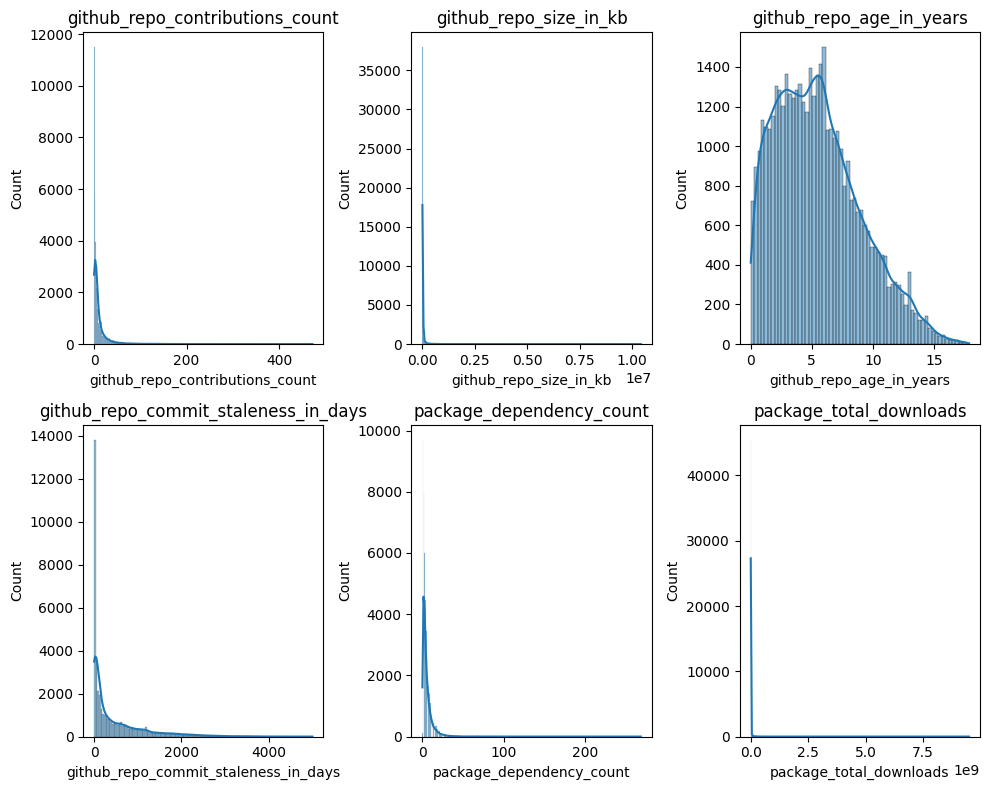

In [41]:
plot_distributions(raw_df.to_pandas(), CONTROL_COLUMNS)

### Predictor Variables Distributions

Individual security practice scores from the OpenSSF Scorecard range from 0 to 10. Most practices exhibit extreme bimodal distributions (scores concentrated at 0 and 10), which is critical context for the PSM treatment threshold and balanced sampling strategy later.

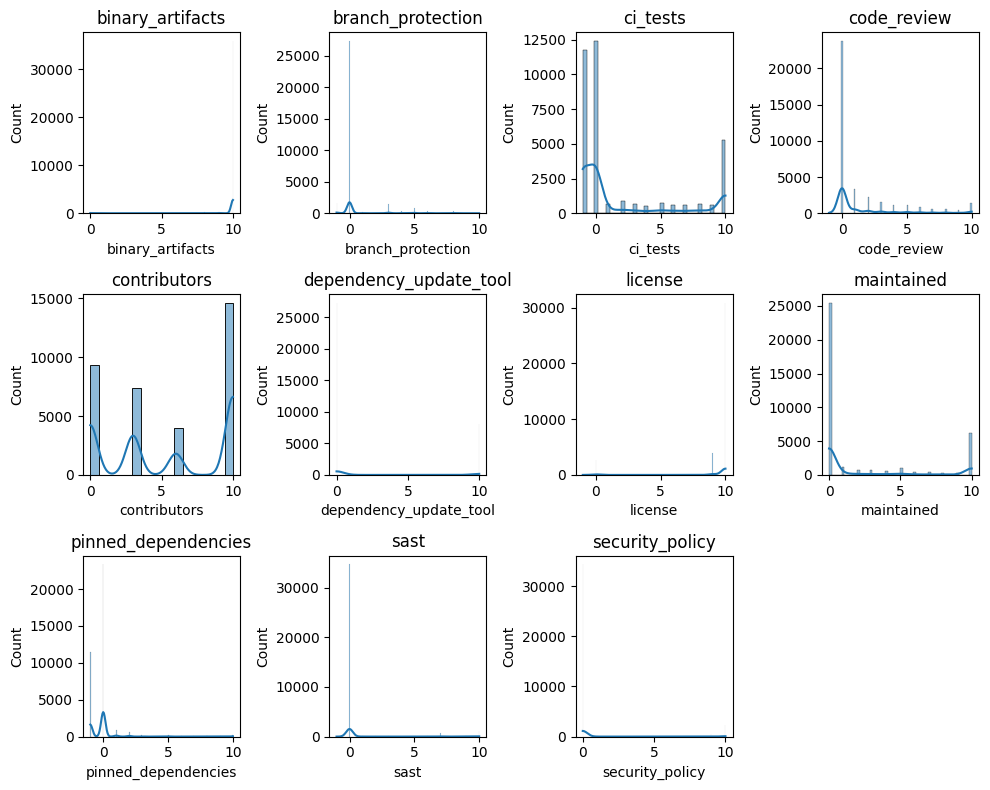

In [42]:
plot_distributions(raw_df.to_pandas(), PREDICTOR_COLUMNS)

### Target Variables Distributions

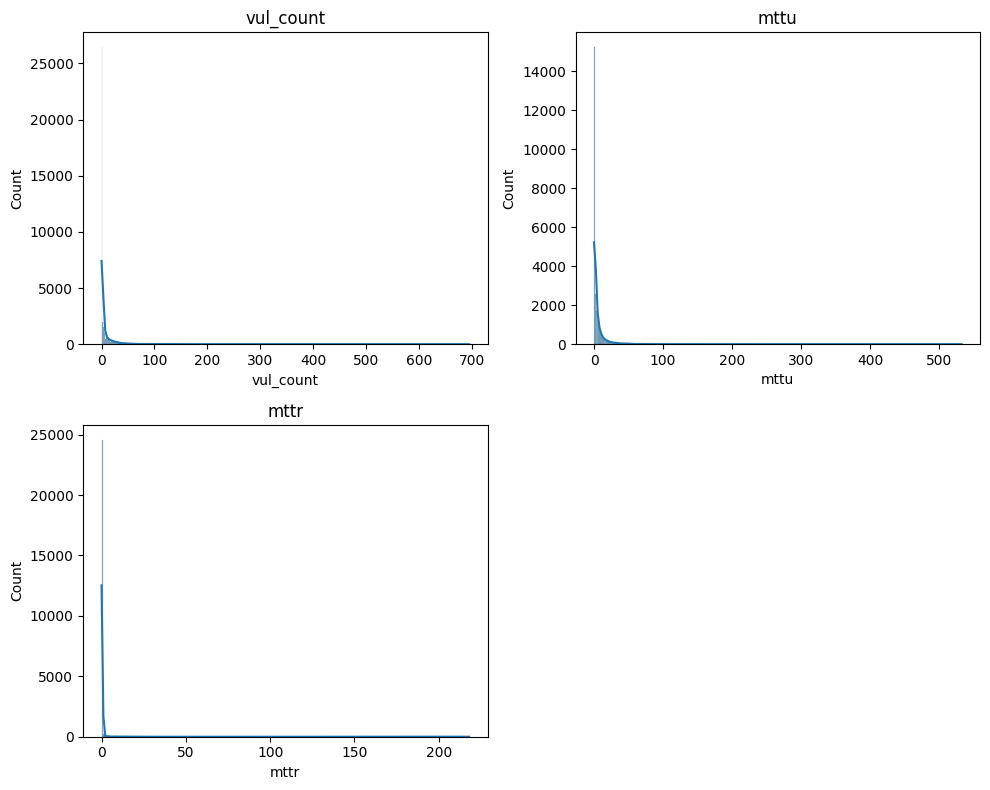

In [43]:
plot_distributions(raw_df.to_pandas(), TARGET_COLUMNS)

In [44]:
for col in [fd.T_MTTR, fd.T_MTTU]:
    s = raw_df.to_pandas()[col]
    print(col)
    print("min:", s.min())
    print("zeros:", (s == 0).sum())
    print("nulls:", s.isna().sum())
    print()

mttr
min: 0.0
zeros: 23930
nulls: 21517

mttu
min: 0.0
zeros: 9731
nulls: 21517



In [45]:
raw_df.select(TARGET_COLUMNS).describe()

statistic,vul_count,mttu,mttr
str,f64,f64,f64
"""count""",37422.0,25262.0,25262.0
"""null_count""",9357.0,21517.0,21517.0
"""mean""",5.830447,5.203273,0.241445
"""std""",22.338919,16.031416,4.072507
"""min""",0.0,0.0,0.0
"""25%""",0.0,0.0,0.0
"""50%""",0.0,0.595051,0.0
"""75%""",3.0,4.358773,0.0
"""max""",694.0,532.619235,217.992199


## Transforming Data

In [46]:
df = (
    raw_df
        .drop_nulls()
        .drop_nans()
        .to_pandas()
)

df[C_LOG_REPOSITORY_CONTRIBUTIONS_COUNT] = np.log1p(df[fd.C_REPOSITORY_CONTRIBUTIONS_COUNT])
df[C_LOG_REPOSITORY_SIZE_IN_KB] = np.log1p(df[fd.C_REPOSITORY_SIZE_IN_KB])
df[C_LOG_REPOSITORY_AGE_IN_YEARS] = np.log1p(df[fd.C_REPOSITORY_AGE_IN_YEARS])
df[C_LOG_REPOSITORY_COMMIT_STALENESS_IN_DAYS] = np.log1p(df[fd.C_REPOSITORY_COMMIT_STALENESS_IN_DAYS])
df[C_LOG_PACKAGE_DEPENDENCY_COUNT] = np.log1p(df[fd.C_PACKAGE_DEPENDENCY_COUNT])
df[C_LOG_PACKAGE_TOTAL_DOWNLOADS] = np.log1p(df[fd.C_PACKAGE_TOTAL_DOWNLOADS])

df[T_LOG_MTTR] = np.log1p(df[fd.T_MTTR])
df[T_LOG_MTTU] = np.log1p(df[fd.T_MTTU])

In [47]:
df.describe()

,package_dependency_count,package_total_downloads,github_repo_age_in_years,github_repo_commit_staleness_in_days,github_repo_contributions_count,github_repo_size_in_kb,binary_artifacts,branch_protection,ci_tests,code_review,...,mttr,mttu,log_github_repo_contributions_count,log_github_repo_size_in_kb,log_github_repo_age_in_years,log_github_repo_commit_staleness_in_days,log_package_dependency_count,log_package_total_downloads,log_mttr,log_mttu
count,15079.000000,1.507900e+04,15079.000000,15079.000000,15079.00000,1.507900e+04,15079.000000,15079.000000,15079.000000,15079.000000,...,15079.000000,15079.000000,15079.000000,15079.000000,15079.000000,15079.000000,15079.000000,15079.000000,15079.000000,15079.000000
mean,6.228530,1.459992e+07,5.338459,308.837721,13.04430,2.906877e+04,9.821208,0.757676,2.710392,1.494462,...,0.239881,5.178941,1.854720,7.122988,1.691042,4.182733,1.663732,11.353758,0.036517,0.899447
std,8.044422,1.493940e+08,3.411250,479.305398,33.01461,2.429145e+05,1.127087,1.820586,4.378591,2.689770,...,4.167778,16.834100,1.075702,2.382841,0.580779,2.235508,0.738210,2.600008,0.285071,1.134056
min,0.000000,6.540000e+02,0.070000,0.000000,0.00000,0.000000e+00,0.000000,0.000000,-1.000000,-1.000000,...,0.000000,0.000000,0.000000,0.000000,0.067659,0.000000,0.000000,6.484635,0.000000,0.000000
25%,2.000000,1.289300e+04,2.560000,13.000000,2.00000,1.945000e+02,10.000000,0.000000,-1.000000,0.000000,...,0.000000,0.000000,1.098612,5.275557,1.269761,2.639057,1.098612,9.464517,0.000000,0.000000
50%,4.000000,4.588700e+04,4.850000,104.000000,4.00000,9.080000e+02,10.000000,0.000000,0.000000,0.000000,...,0.000000,0.339052,1.609438,6.812345,1.766442,4.653960,1.609438,10.733959,0.000000,0.291962
75%,7.000000,3.256790e+05,7.380000,418.000000,11.00000,6.425500e+03,10.000000,0.000000,7.000000,2.000000,...,0.000000,4.079394,2.484907,8.768185,2.125848,6.037871,2.079442,12.693671,0.000000,1.625192
max,268.000000,6.453635e+09,17.550000,4106.000000,470.00000,1.040426e+07,10.000000,10.000000,10.000000,10.000000,...,217.992199,532.619235,6.154858,16.157726,2.920470,8.320448,5.594711,22.587909,5.389036,6.279683


### Effective Sample Size: After Filtering

In [48]:
n_filtered = len(df)
n_dropped = n_initial - n_filtered
n_mttr_positive = (df[fd.T_MTTR] > 0).sum()
n_mttu_positive = (df[fd.T_MTTU] > 0).sum()

print("=" * 60)
print("STAGE 2 — After drop_nulls / drop_nans")
print("=" * 60)
print(f"  Rows retained:               {n_filtered:>8,}")
print(f"  Rows dropped (null/NaN):     {n_dropped:>8,}  ({n_dropped / n_initial:.1%} of initial)")
print()
print("  Per-target effective N (rows with outcome > 0):")
print(f"    Vul_Count (all rows):      {n_filtered:>8,}")
print(f"    MTTR (> 0):                {n_mttr_positive:>8,}  ({n_mttr_positive / n_filtered:.1%} of filtered)")
print(f"    MTTU (> 0):                {n_mttu_positive:>8,}  ({n_mttu_positive / n_filtered:.1%} of filtered)")
print()
print(f"  Paper used 145,817 for Vul_Count/MTTU and 22,412 for MTTR.")

STAGE 2 — After drop_nulls / drop_nans
  Rows retained:                 15,079
  Rows dropped (null/NaN):       31,700  (67.8% of initial)

  Per-target effective N (rows with outcome > 0):
    Vul_Count (all rows):        15,079
    MTTR (> 0):                     673  (4.5% of filtered)
    MTTU (> 0):                   8,779  (58.2% of filtered)

  Paper used 145,817 for Vul_Count/MTTU and 22,412 for MTTR.


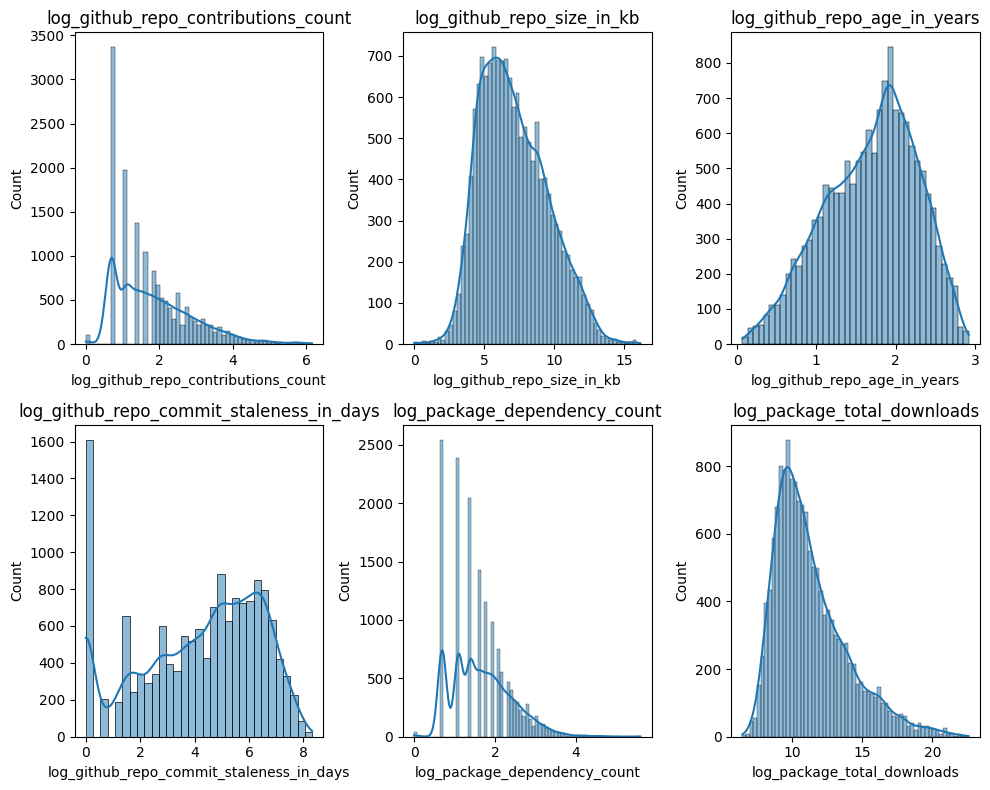

In [49]:
plot_distributions(df, LOG_CONTROL_COLUMNS)

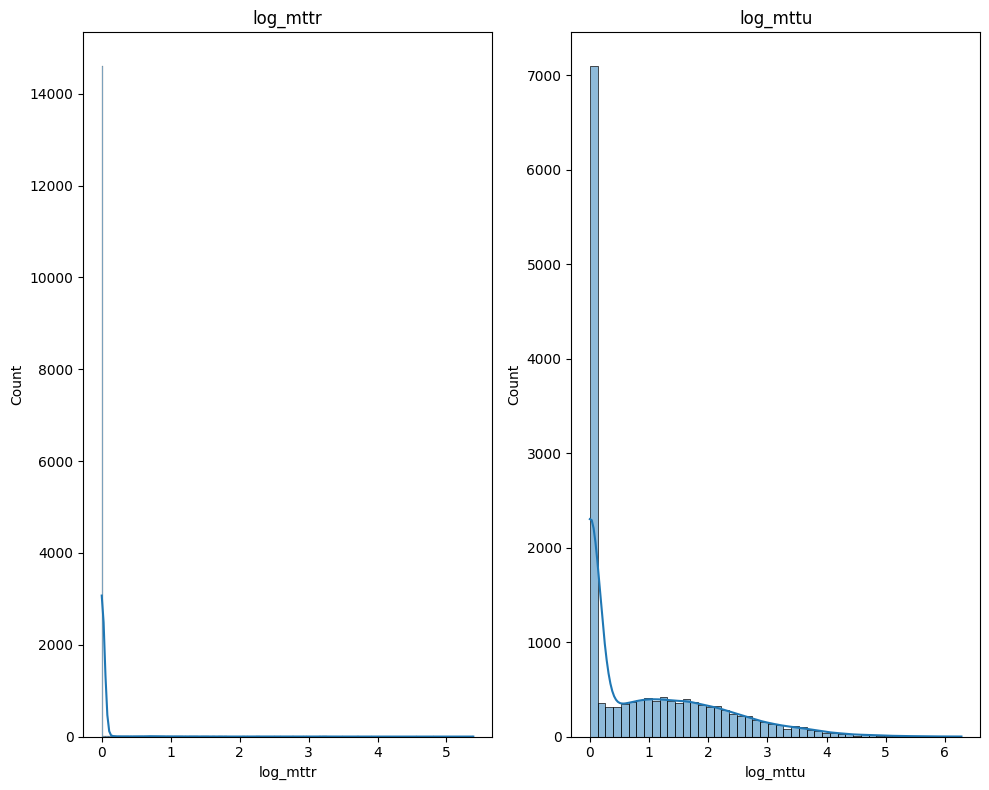

In [50]:
plot_distributions(df, [T_LOG_MTTR, T_LOG_MTTU])

## Modeling

Following the reference paper (Section 6.1.1), we use Random Forest (RF) regression to model the relationship between individual security practices and each outcome variable. RF is chosen for its ability to capture non-linear interactions between practices and its built-in feature importance mechanism (Gini importance / mean decrease in impurity).

We train separate RF models for each outcome (Vul_Count, MTTR, MTTU) using the 11 individual security practice scores as features and the 6 log-transformed control variables as additional predictors. Model configuration follows the paper: `n_estimators=100`, `random_state=42`, 70/30 train/test split, with 5-fold cross-validation to assess generalization.

In [51]:
feature_columns = PREDICTOR_COLUMNS + LOG_CONTROL_COLUMNS
X = df[feature_columns]

### Target: Vul_Count

In [52]:
y_vul = df[fd.T_VULNERABILITY_COUNT]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_vul, test_size=0.3, random_state=42
)

rf_vul = RandomForestRegressor(n_estimators=100, random_state=42)
rf_vul.fit(X_train, y_train)

test_score = rf_vul.score(X_test, y_test)
cv_scores = cross_val_score(rf_vul, X, y_vul, cv=5, scoring="r2")

print(f"Test R²: {test_score:.4f}")
print(f"5-Fold CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Test R²: 0.3212
5-Fold CV R²: 0.0512 (+/- 0.0292)


### Target: MTTR

In [53]:
mttr_mask = df[fd.T_MTTR] > 0
X_mttr = df.loc[mttr_mask, feature_columns]
y_mttr = df.loc[mttr_mask, fd.T_MTTR]

X_train, X_test, y_train, y_test = train_test_split(
    X_mttr, y_mttr, test_size=0.3, random_state=42
)

rf_mttr = RandomForestRegressor(n_estimators=100, random_state=42)
rf_mttr.fit(X_train, y_train)

test_score = rf_mttr.score(X_test, y_test)
cv_scores = cross_val_score(rf_mttr, X_mttr, y_mttr, cv=5, scoring="r2")

print(f"Test R²: {test_score:.4f}")
print(f"5-Fold CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Test R²: 0.5973
5-Fold CV R²: -0.1451 (+/- 0.7786)


### Target: MTTU

In [54]:
mttu_mask = df[fd.T_MTTU] > 0
X_mttu = df.loc[mttu_mask, feature_columns]
y_mttu = df.loc[mttu_mask, fd.T_MTTU]

X_train, X_test, y_train, y_test = train_test_split(
    X_mttu, y_mttu, test_size=0.3, random_state=42
)

rf_mttu = RandomForestRegressor(n_estimators=100, random_state=42)
rf_mttu.fit(X_train, y_train)

test_score = rf_mttu.score(X_test, y_test)
cv_scores = cross_val_score(rf_mttu, X_mttu, y_mttu, cv=5, scoring="r2")

print(f"Test R²: {test_score:.4f}")
print(f"5-Fold CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

Test R²: 0.1171
5-Fold CV R²: 0.0388 (+/- 0.0605)


## Feature Importance Ranking

We extract Gini importance (mean decrease in impurity) from each Random Forest model and apply dense ranking. Since control variables are included in the model as confounders but are not security practices themselves, we separate them when computing the importance ranking. We then select the top security practices that account for approximately 80% of cumulative importance across the models. These top-ranked practices will be the focus of the subsequent PSM analysis.

In [55]:
def get_feature_importance(model, feature_names):
    """Extract Gini importance from RF model and return sorted DataFrame."""
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False)
    importance_df["rank"] = importance_df["importance"].rank(method="dense", ascending=False).astype(int)
    importance_df["cumulative_importance"] = importance_df["importance"].cumsum()
    importance_df["cumulative_pct"] = importance_df["cumulative_importance"] / importance_df["importance"].sum()
    return importance_df

importance_vul = get_feature_importance(rf_vul, feature_columns)
importance_mttr = get_feature_importance(rf_mttr, feature_columns)
importance_mttu = get_feature_importance(rf_mttu, feature_columns)

print("=== Vul_Count Feature Importance ===")
print(importance_vul.to_string(index=False))
print("\n=== MTTR Feature Importance ===")
print(importance_mttr.to_string(index=False))
print("\n=== MTTU Feature Importance ===")
print(importance_mttu.to_string(index=False))

=== Vul_Count Feature Importance ===
                                 feature  importance  rank  cumulative_importance  cumulative_pct
log_github_repo_commit_staleness_in_days    0.163747     1               0.163747        0.163747
             log_package_total_downloads    0.154123     2               0.317870        0.317870
              log_github_repo_size_in_kb    0.149589     3               0.467459        0.467459
            log_github_repo_age_in_years    0.125213     4               0.592672        0.592672
     log_github_repo_contributions_count    0.097953     5               0.690625        0.690625
            log_package_dependency_count    0.091664     6               0.782289        0.782289
                             code_review    0.039888     7               0.822177        0.822177
                            contributors    0.029318     8               0.851495        0.851495
                                ci_tests    0.027572     9               0.879067

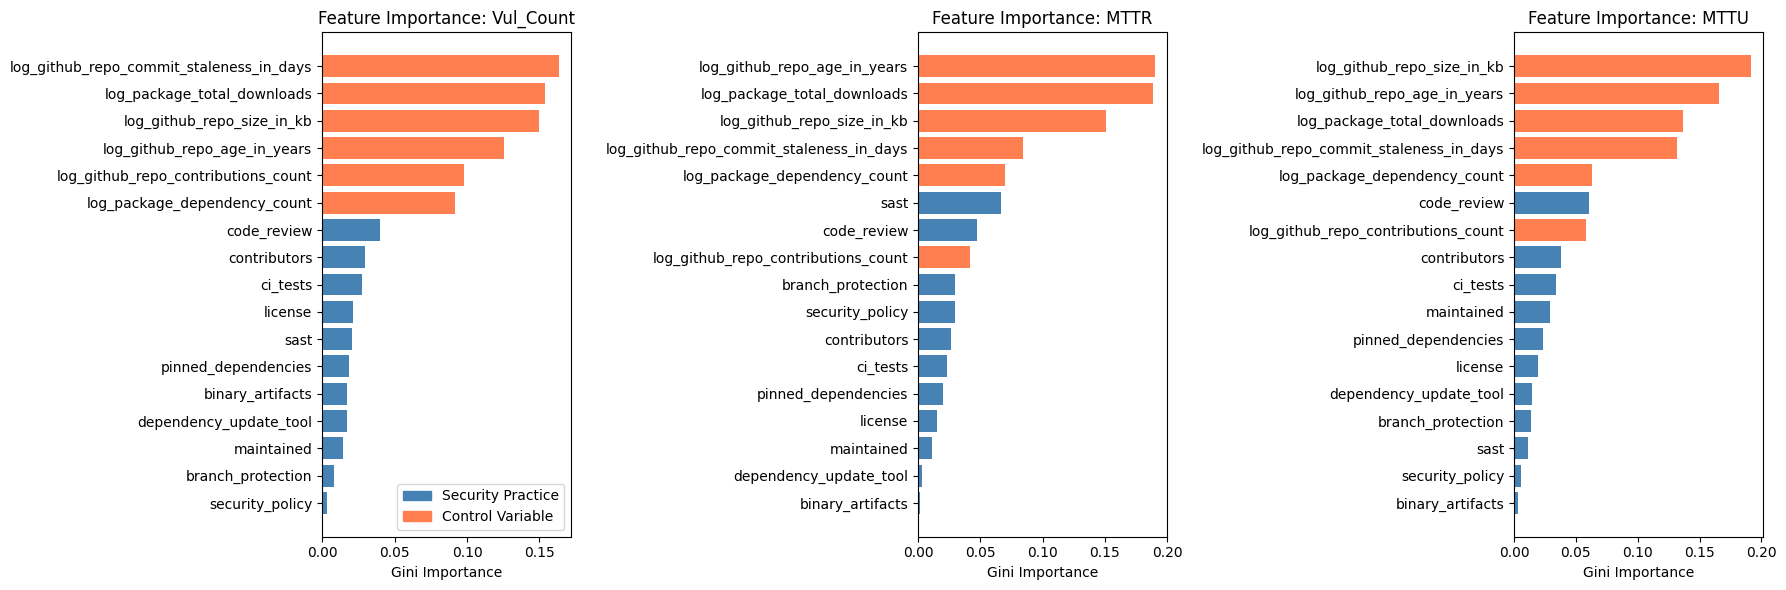

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (imp_df, title) in zip(axes, [
    (importance_vul, "Vul_Count"),
    (importance_mttr, "MTTR"),
    (importance_mttu, "MTTU"),
]):
    colors = ["steelblue" if f in PREDICTOR_COLUMNS else "coral" for f in imp_df["feature"]]
    ax.barh(imp_df["feature"], imp_df["importance"], color=colors)
    ax.set_xlabel("Gini Importance")
    ax.set_title(f"Feature Importance: {title}")
    ax.invert_yaxis()

axes[0].legend(
    handles=[Patch(color="steelblue", label="Security Practice"),
             Patch(color="coral", label="Control Variable")],
    loc="lower right"
)

plt.tight_layout()
plt.show()

In [57]:
def select_top_practices(importance_df, predictor_columns, threshold=0.80):
    """Select security practices accounting for threshold% of practice-only importance."""
    practice_imp = importance_df[importance_df["feature"].isin(predictor_columns)].copy()
    practice_imp = practice_imp.sort_values("importance", ascending=False).reset_index(drop=True)
    practice_imp["practice_cumulative_pct"] = (
        practice_imp["importance"].cumsum() / practice_imp["importance"].sum()
    )
    selected = practice_imp[practice_imp["practice_cumulative_pct"].shift(1, fill_value=0) < threshold]
    return selected["feature"].tolist()

top_practices_vul = select_top_practices(importance_vul, PREDICTOR_COLUMNS)
top_practices_mttr = select_top_practices(importance_mttr, PREDICTOR_COLUMNS)
top_practices_mttu = select_top_practices(importance_mttu, PREDICTOR_COLUMNS)

# Union of top practices across all three outcomes
TOP_PRACTICES = sorted(set(top_practices_vul + top_practices_mttr + top_practices_mttu))

print(f"Top practices (Vul_Count):  {top_practices_vul}")
print(f"Top practices (MTTR):       {top_practices_mttr}")
print(f"Top practices (MTTU):       {top_practices_mttu}")
print(f"\nUnion for PSM ({len(TOP_PRACTICES)}): {TOP_PRACTICES}")

Top practices (Vul_Count):  ['code_review', 'contributors', 'ci_tests', 'license', 'sast', 'pinned_dependencies', 'binary_artifacts']
Top practices (MTTR):       ['sast', 'code_review', 'branch_protection', 'security_policy', 'contributors', 'ci_tests']
Top practices (MTTU):       ['code_review', 'contributors', 'ci_tests', 'maintained', 'pinned_dependencies', 'license']

Union for PSM (10): ['binary_artifacts', 'branch_protection', 'ci_tests', 'code_review', 'contributors', 'license', 'maintained', 'pinned_dependencies', 'sast', 'security_policy']


## Propensity Score Matching (PSM)

Propensity Score Matching strengthens our causal argument by creating comparable treatment and control groups for each individual security practice. Unlike RQ1, which used a single aggregated score, RQ2 requires running PSM separately for each top-ranked practice.

Since individual practice scores in OSSF Scorecard tend to be extremely bimodal (most packages score 0 or 10, with few intermediate values), we apply a universal treatment threshold of 5.0: packages scoring >= 5 on a given practice are classified as "treated" and those scoring < 5 as "control." Following the reference paper, we apply balanced downsampling of the majority class before PSM to ensure sufficient overlap in propensity score distributions.

For each practice, we follow the same PSM pipeline:
1. Define treatment from the threshold
2. Balance the sample via downsampling
3. Estimate propensity scores via logistic regression on control variables
4. Nearest-neighbor matching with caliper = 0.1 * std(propensity_score)
5. Assess covariate balance via SMD
6. Compute Average Treatment Effect (ATE) via bootstrap

### Step 1: Define Treatment Variables

PSM requires a binary treatment indicator. Following the reference paper, we use a universal threshold of 5.0 for all security practices. Packages with a practice score >= 5 are classified as "treated" (adopters), and those with a score < 5 as "control" (non-adopters).

We first inspect the class distribution for each practice to understand the imbalance.

In [58]:
print(f"Treatment threshold: {TREATMENT_THRESHOLD}\n")

treatment_stats = []
for practice in TOP_PRACTICES:
    treated = (df[practice] >= TREATMENT_THRESHOLD).sum()
    control = (df[practice] < TREATMENT_THRESHOLD).sum()
    ratio = treated / control if control > 0 else float("inf")
    treatment_stats.append({
        "practice": practice,
        "treated": treated,
        "control": control,
        "treated_pct": f"{treated / len(df):.1%}",
        "imbalance_ratio": f"{ratio:.2f}",
    })

treatment_stats_df = pd.DataFrame(treatment_stats)
print(treatment_stats_df.to_string(index=False))

Treatment threshold: 5.0

           practice  treated  control treated_pct imbalance_ratio
   binary_artifacts    14881      198       98.7%           75.16
  branch_protection     1171    13908        7.8%            0.08
           ci_tests     4701    10378       31.2%            0.45
        code_review     2038    13041       13.5%            0.16
       contributors     8808     6271       58.4%            1.40
            license    14008     1071       92.9%           13.08
         maintained     4552    10527       30.2%            0.43
pinned_dependencies      449    14630        3.0%            0.03
               sast     1049    14030        7.0%            0.07
    security_policy     1330    13749        8.8%            0.10


### Step 2: Balanced Sampling

Many individual security practices have extreme class imbalance (e.g., 95%+ in one group). Standard PSM fails in such cases because propensity score distributions have minimal overlap. Following the reference paper, we downsample the majority class to match the minority class size before estimating propensity scores. This ensures sufficient common support for matching.

In [59]:
def create_balanced_sample(data, practice, threshold, random_state=42):
    """Downsample majority class to match minority class size."""
    treated = data[data[practice] >= threshold]
    control = data[data[practice] < threshold]

    minority_size = min(len(treated), len(control))

    if len(treated) > minority_size:
        treated = treated.sample(n=minority_size, random_state=random_state)
    if len(control) > minority_size:
        control = control.sample(n=minority_size, random_state=random_state)

    balanced = pd.concat([treated, control]).reset_index(drop=True)
    balanced["treated"] = (balanced[practice] >= threshold).astype(int)

    return balanced

# Preview balanced sample sizes
for practice in TOP_PRACTICES:
    balanced = create_balanced_sample(df, practice, TREATMENT_THRESHOLD)
    n_treated = balanced["treated"].sum()
    n_control = (balanced["treated"] == 0).sum()
    print(f"{practice}: {n_treated} treated, {n_control} control (total: {len(balanced)})")

binary_artifacts: 198 treated, 198 control (total: 396)
branch_protection: 1171 treated, 1171 control (total: 2342)
ci_tests: 4701 treated, 4701 control (total: 9402)
code_review: 2038 treated, 2038 control (total: 4076)
contributors: 6271 treated, 6271 control (total: 12542)
license: 1071 treated, 1071 control (total: 2142)
maintained: 4552 treated, 4552 control (total: 9104)
pinned_dependencies: 449 treated, 449 control (total: 898)
sast: 1049 treated, 1049 control (total: 2098)
security_policy: 1330 treated, 1330 control (total: 2660)


### Steps 3-6: PSM Pipeline per Practice

We now run the full PSM pipeline for each top-ranked security practice. For each practice, we:

1. Create a balanced sample
2. Estimate propensity scores via logistic regression on log-transformed controls
3. Perform nearest-neighbor matching with caliper = 0.1 * std(propensity_score), without replacement, greedy by distance
4. Assess covariate balance via Standardized Mean Differences (SMD)
5. Compute bootstrap ATE (2,000 iterations) for each outcome (Vul_Count, MTTR, MTTU)

All results are collected into summary DataFrames for comparison across practices.

In [60]:
def estimate_propensity_scores(data, log_control_columns):
    """Fit logistic regression and return propensity scores."""
    X_ps = data[log_control_columns]
    y_ps = data["treated"]

    ps_model = LogisticRegression(max_iter=1000, solver="lbfgs")
    ps_model.fit(X_ps, y_ps)

    data = data.copy()
    data["propensity_score"] = ps_model.predict_proba(X_ps)[:, 1]
    return data


def nearest_neighbor_match(data, caliper_multiplier=0.1):
    """Nearest-neighbor matching with caliper, without replacement, greedy."""
    caliper = caliper_multiplier * data["propensity_score"].std()

    treated_idx = data.index[data["treated"] == 1].values
    control_idx = data.index[data["treated"] == 0].values

    treated_ps = data.loc[treated_idx, "propensity_score"].values.reshape(-1, 1)
    control_ps = data.loc[control_idx, "propensity_score"].values.reshape(-1, 1)

    nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
    nn.fit(control_ps)
    distances, indices = nn.kneighbors(treated_ps)

    matched_treated, matched_control = [], []
    used_control = set()

    for i in np.argsort(distances.flatten()):
        if distances[i, 0] > caliper:
            continue
        ctrl_local = indices[i, 0]
        if ctrl_local in used_control:
            continue
        matched_treated.append(treated_idx[i])
        matched_control.append(control_idx[ctrl_local])
        used_control.add(ctrl_local)

    matched_idx = np.array(matched_treated + matched_control)
    matched_df = data.loc[matched_idx].copy()

    return matched_df, len(matched_treated), caliper


def compute_smd(data, covariates, treatment_col="treated"):
    """Compute Standardized Mean Differences."""
    treated = data[data[treatment_col] == 1]
    control = data[data[treatment_col] == 0]
    results = {}
    for cov in covariates:
        mean_diff = treated[cov].mean() - control[cov].mean()
        pooled_std = np.sqrt((treated[cov].var() + control[cov].var()) / 2)
        results[cov] = mean_diff / pooled_std if pooled_std > 0 else 0.0
    return results


def compute_ate(data, outcome_col):
    """Compute Average Treatment Effect."""
    return (data.loc[data["treated"] == 1, outcome_col].mean()
          - data.loc[data["treated"] == 0, outcome_col].mean())


def bootstrap_ate(data, outcome_col, n_bootstrap=2000, seed=42):
    """Bootstrap ATE with 95% CI."""
    rng = np.random.RandomState(seed)
    estimates = []
    for _ in range(n_bootstrap):
        boot = data.sample(n=len(data), replace=True, random_state=rng)
        estimates.append(compute_ate(boot, outcome_col))
    estimates = np.array(estimates)
    return {
        "ate": compute_ate(data, outcome_col),
        "ci_lower": np.percentile(estimates, 2.5),
        "ci_upper": np.percentile(estimates, 97.5),
        "significant": not (np.percentile(estimates, 2.5) <= 0 <= np.percentile(estimates, 97.5)),
        "distribution": estimates,
    }

In [61]:
outcomes = [
    ("Vul_Count", fd.T_VULNERABILITY_COUNT),
    ("MTTR", fd.T_MTTR),
    ("MTTU", fd.T_MTTU),
]

psm_results = {}

for practice in TOP_PRACTICES:
    print(f"\n{'='*60}")
    print(f"PSM for: {practice}")
    print(f"{'='*60}")

    # Step 2: Balanced sampling
    balanced_df = create_balanced_sample(df, practice, TREATMENT_THRESHOLD)
    print(f"Balanced sample: {balanced_df['treated'].sum()} treated, "
          f"{(balanced_df['treated'] == 0).sum()} control")

    # Step 3: Propensity scores
    balanced_df = estimate_propensity_scores(balanced_df, LOG_CONTROL_COLUMNS)

    # Step 3: Nearest-neighbor matching
    matched_df, match_count, caliper = nearest_neighbor_match(balanced_df)
    print(f"Matched pairs: {match_count}, Caliper: {caliper:.4f}")

    if match_count < 30:
        print(f"WARNING: Only {match_count} matched pairs. Results may be unreliable.")

    # Step 4: Covariate balance
    smd_before = compute_smd(balanced_df, LOG_CONTROL_COLUMNS)
    smd_after = compute_smd(matched_df, LOG_CONTROL_COLUMNS)

    max_smd_after = max(abs(v) for v in smd_after.values())
    print(f"Max |SMD| after matching: {max_smd_after:.4f} "
          f"({'GOOD' if max_smd_after < 0.1 else 'CHECK BALANCE'})")

    # Steps 5-6: ATE for each outcome
    ate_results = {}
    for outcome_name, outcome_col in outcomes:
        analysis_df = matched_df.dropna(subset=[outcome_col])
        if outcome_col in [fd.T_MTTR, fd.T_MTTU]:
            analysis_df = analysis_df[analysis_df[outcome_col] > 0]

        if len(analysis_df) < 20 or analysis_df["treated"].nunique() < 2:
            print(f"  {outcome_name}: Insufficient data after filtering (n={len(analysis_df)})")
            ate_results[outcome_name] = None
            continue

        result = bootstrap_ate(analysis_df, outcome_col)
        ate_results[outcome_name] = result
        sig = "*" if result["significant"] else ""
        print(f"  {outcome_name}: ATE = {result['ate']:.4f} "
              f"[{result['ci_lower']:.4f}, {result['ci_upper']:.4f}]{sig}")

    psm_results[practice] = {
        "matched_df": matched_df,
        "match_count": match_count,
        "caliper": caliper,
        "smd_before": smd_before,
        "smd_after": smd_after,
        "ate_results": ate_results,
    }


PSM for: binary_artifacts
Balanced sample: 198 treated, 198 control
Matched pairs: 73, Caliper: 0.0285
Max |SMD| after matching: 0.1367 (CHECK BALANCE)
  Vul_Count: ATE = 2.1096 [-4.2727, 8.8908]
  MTTR: Insufficient data after filtering (n=2)
  MTTU: ATE = 1.6738 [-6.2934, 7.6171]

PSM for: branch_protection
Balanced sample: 1171 treated, 1171 control
Matched pairs: 398, Caliper: 0.0274
Max |SMD| after matching: 0.0855 (GOOD)
  Vul_Count: ATE = -3.5101 [-6.9115, -0.7454]*
  MTTR: ATE = -0.3676 [-1.8117, 0.9580]
  MTTU: ATE = 0.9655 [-3.8321, 6.5258]

PSM for: ci_tests
Balanced sample: 4701 treated, 4701 control
Matched pairs: 1311, Caliper: 0.0314
Max |SMD| after matching: 0.0571 (GOOD)
  Vul_Count: ATE = -0.7941 [-2.1720, 0.4228]
  MTTR: ATE = 0.5212 [-2.6429, 3.6585]
  MTTU: ATE = -1.6031 [-3.6064, 0.3000]

PSM for: code_review
Balanced sample: 2038 treated, 2038 control
Matched pairs: 648, Caliper: 0.0287
Max |SMD| after matching: 0.0545 (GOOD)
  Vul_Count: ATE = 1.4275 [-0.5813, 

### Effective Sample Size: After PSM Matching

RQ2 runs a separate PSM pipeline per security practice. The table below
consolidates sample sizes at every stage — initial, filtered, balanced,
and matched — so a reader can assess where statistical power is lost
relative to the paper's reported counts.

In [62]:
# --- Per-practice PSM sample-size summary ---
psm_size_rows = []
for practice in TOP_PRACTICES:
    result = psm_results[practice]
    mdf = result["matched_df"]
    n_treated_pre = (df[practice] >= TREATMENT_THRESHOLD).sum()
    n_control_pre = (df[practice] < TREATMENT_THRESHOLD).sum()
    minority = min(n_treated_pre, n_control_pre)
    balanced_n = minority * 2
    matched_n = len(mdf)
    matched_pairs = result["match_count"]
    n_matched_mttr = ((mdf[fd.T_MTTR] > 0) & mdf[fd.T_MTTR].notna()).sum()
    n_matched_mttu = ((mdf[fd.T_MTTU] > 0) & mdf[fd.T_MTTU].notna()).sum()

    psm_size_rows.append({
        "Practice": practice,
        "Pre-balance Treated": n_treated_pre,
        "Pre-balance Control": n_control_pre,
        "Balanced N": balanced_n,
        "Matched Pairs": matched_pairs,
        "Matched N": matched_n,
        "Match Rate": f"{matched_pairs / minority:.1%}",
        "Matched MTTR (>0)": n_matched_mttr,
        "Matched MTTU (>0)": n_matched_mttu,
    })

psm_size_df = pd.DataFrame(psm_size_rows).set_index("Practice")
print("=" * 60)
print("STAGE 3 — Per-Practice PSM Sample Sizes")
print("=" * 60)
print(psm_size_df.to_string())

# --- Consolidated pipeline summary ---
print()
print("=" * 60)
print("CONSOLIDATED SAMPLE-SIZE PIPELINE")
print("=" * 60)

pipeline = pd.DataFrame([
    {"Stage": "1. Initial (loaded)",       "N": n_initial,         "Vul_Count": n_initial,         "MTTR (>0)": n_initial_non_null_mttr, "MTTU (>0)": n_initial_non_null_mttu},
    {"Stage": "2. Filtered (no null/NaN)", "N": n_filtered,        "Vul_Count": n_filtered,        "MTTR (>0)": n_mttr_positive,         "MTTU (>0)": n_mttu_positive},
    {"Stage": "— Paper: full sample",      "N": PAPER_N_SCORECARD, "Vul_Count": PAPER_N_SCORECARD, "MTTR (>0)": PAPER_N_MTTR,            "MTTU (>0)": "—"},
])
pipeline = pipeline.set_index("Stage")
print(pipeline.to_string())
print()
print("Per-practice matched sizes (see table above) vary due to class")
print("imbalance in individual security practice adoption rates.")

STAGE 3 — Per-Practice PSM Sample Sizes
                     Pre-balance Treated  Pre-balance Control  Balanced N  Matched Pairs  Matched N Match Rate  Matched MTTR (>0)  Matched MTTU (>0)
Practice                                                                                                                                            
binary_artifacts                   14881                  198         396             73        146      36.9%                  2                 92
branch_protection                   1171                13908        2342            398        796      34.0%                 29                496
ci_tests                            4701                10378        9402           1311       2622      27.9%                 87               1569
code_review                         2038                13041        4076            648       1296      31.8%                 49                797
contributors                        8808                 6271     

### Covariate Balance Assessment

We visualize covariate balance for all practices using Love plots. After matching, all absolute SMDs should fall below 0.1. Practices where balance is not achieved may have unreliable treatment effect estimates.

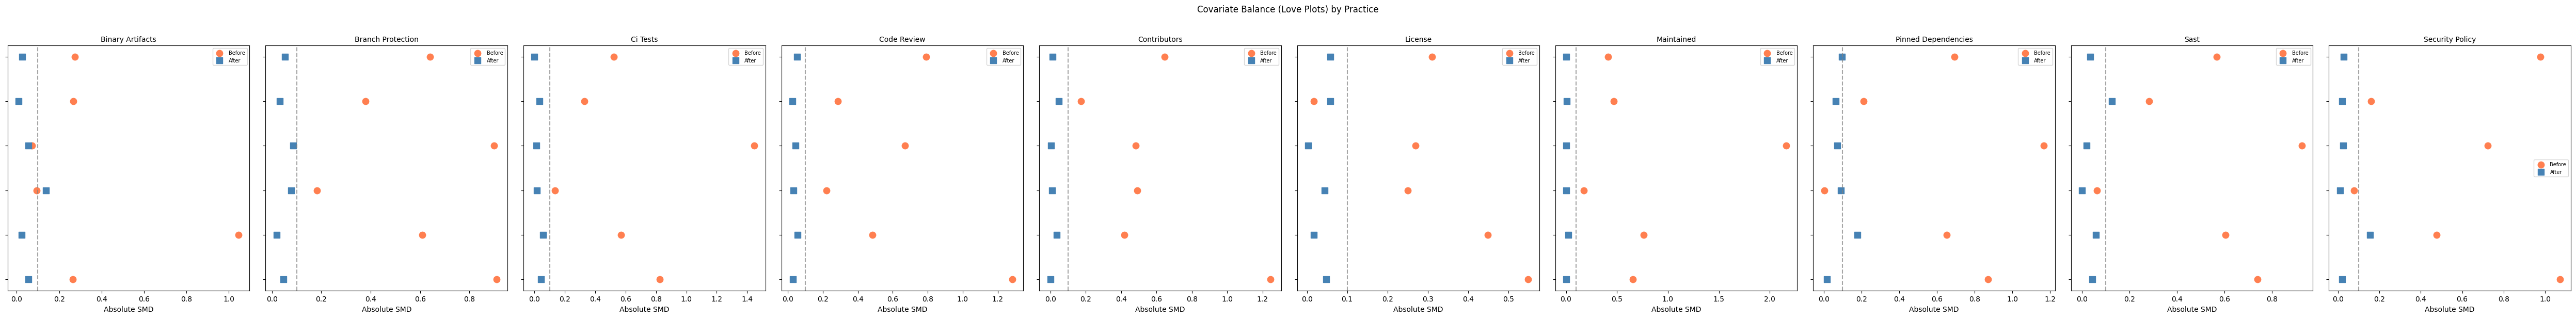

In [63]:
n_practices = len(TOP_PRACTICES)
fig, axes = plt.subplots(1, n_practices, figsize=(5 * n_practices, 6), sharey=True)
if n_practices == 1:
    axes = [axes]

labels = [c.replace("log_", "").replace("_", " ").title() for c in LOG_CONTROL_COLUMNS]

for ax, practice in zip(axes, TOP_PRACTICES):
    result = psm_results[practice]
    smd_before = result["smd_before"]
    smd_after = result["smd_after"]

    ax.scatter([abs(v) for v in smd_before.values()], range(len(labels)),
               marker="o", color="coral", s=80, label="Before")
    ax.scatter([abs(v) for v in smd_after.values()], range(len(labels)),
               marker="s", color="steelblue", s=80, label="After")
    ax.axvline(0.1, color="gray", linestyle="--", alpha=0.7)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels if ax == axes[0] else [])
    ax.set_xlabel("Absolute SMD")
    ax.set_title(practice.replace("_", " ").title(), fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle("Covariate Balance (Love Plots) by Practice", y=1.02)
plt.tight_layout()
plt.show()

### Average Treatment Effect (ATE) Summary

The ATE measures the mean difference in outcomes between matched treated (adopters) and control (non-adopters) groups for each security practice. We use bootstrap resampling (2,000 iterations) to construct 95% confidence intervals. A negative ATE for Vul_Count means the practice is associated with fewer vulnerabilities; a negative ATE for MTTR/MTTU means faster recovery/update times. If the CI excludes zero, the effect is statistically significant at the 5% level (marked with *).

In [64]:
ate_rows = []
for practice in TOP_PRACTICES:
    result = psm_results[practice]
    for outcome_name in ["Vul_Count", "MTTR", "MTTU"]:
        ate = result["ate_results"].get(outcome_name)
        if ate is None:
            ate_rows.append({
                "Practice": practice,
                "Outcome": outcome_name,
                "ATE": None,
                "CI_Lower": None,
                "CI_Upper": None,
                "Significant": None,
                "N_Matched_Pairs": result["match_count"],
            })
        else:
            ate_rows.append({
                "Practice": practice,
                "Outcome": outcome_name,
                "ATE": round(ate["ate"], 4),
                "CI_Lower": round(ate["ci_lower"], 4),
                "CI_Upper": round(ate["ci_upper"], 4),
                "Significant": ate["significant"],
                "N_Matched_Pairs": result["match_count"],
            })

ate_summary_df = pd.DataFrame(ate_rows)
print(ate_summary_df.to_string(index=False))

           Practice   Outcome     ATE  CI_Lower  CI_Upper Significant  N_Matched_Pairs
   binary_artifacts Vul_Count  2.1096   -4.2727    8.8908       False               73
   binary_artifacts      MTTR     NaN       NaN       NaN        None               73
   binary_artifacts      MTTU  1.6738   -6.2934    7.6171       False               73
  branch_protection Vul_Count -3.5101   -6.9115   -0.7454        True              398
  branch_protection      MTTR -0.3676   -1.8117    0.9580       False              398
  branch_protection      MTTU  0.9655   -3.8321    6.5258       False              398
           ci_tests Vul_Count -0.7941   -2.1720    0.4228       False             1311
           ci_tests      MTTR  0.5212   -2.6429    3.6585       False             1311
           ci_tests      MTTU -1.6031   -3.6064    0.3000       False             1311
        code_review Vul_Count  1.4275   -0.5813    3.7990       False              648
        code_review      MTTR  5.3028   -2.

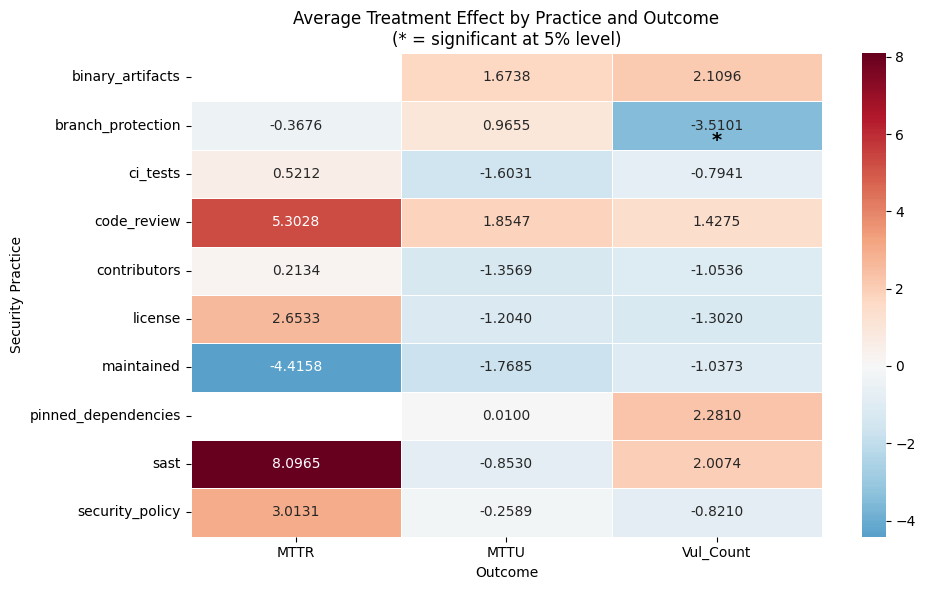

In [65]:
# Pivot ATE values for heatmap
ate_pivot = ate_summary_df.pivot(index="Practice", columns="Outcome", values="ATE")
sig_pivot = ate_summary_df.pivot(index="Practice", columns="Outcome", values="Significant")

fig, ax = plt.subplots(figsize=(10, max(6, len(TOP_PRACTICES) * 0.6)))
sns.heatmap(
    ate_pivot.astype(float),
    annot=True,
    fmt=".4f",
    cmap="RdBu_r",
    center=0,
    ax=ax,
    linewidths=0.5,
)

# Add significance markers
for i in range(ate_pivot.shape[0]):
    for j in range(ate_pivot.shape[1]):
        if sig_pivot.iloc[i, j]:
            ax.text(j + 0.5, i + 0.8, "*", ha="center", va="center",
                    fontsize=14, fontweight="bold", color="black")

ax.set_title("Average Treatment Effect by Practice and Outcome\n(* = significant at 5% level)")
ax.set_ylabel("Security Practice")
ax.set_xlabel("Outcome")
plt.tight_layout()
plt.show()

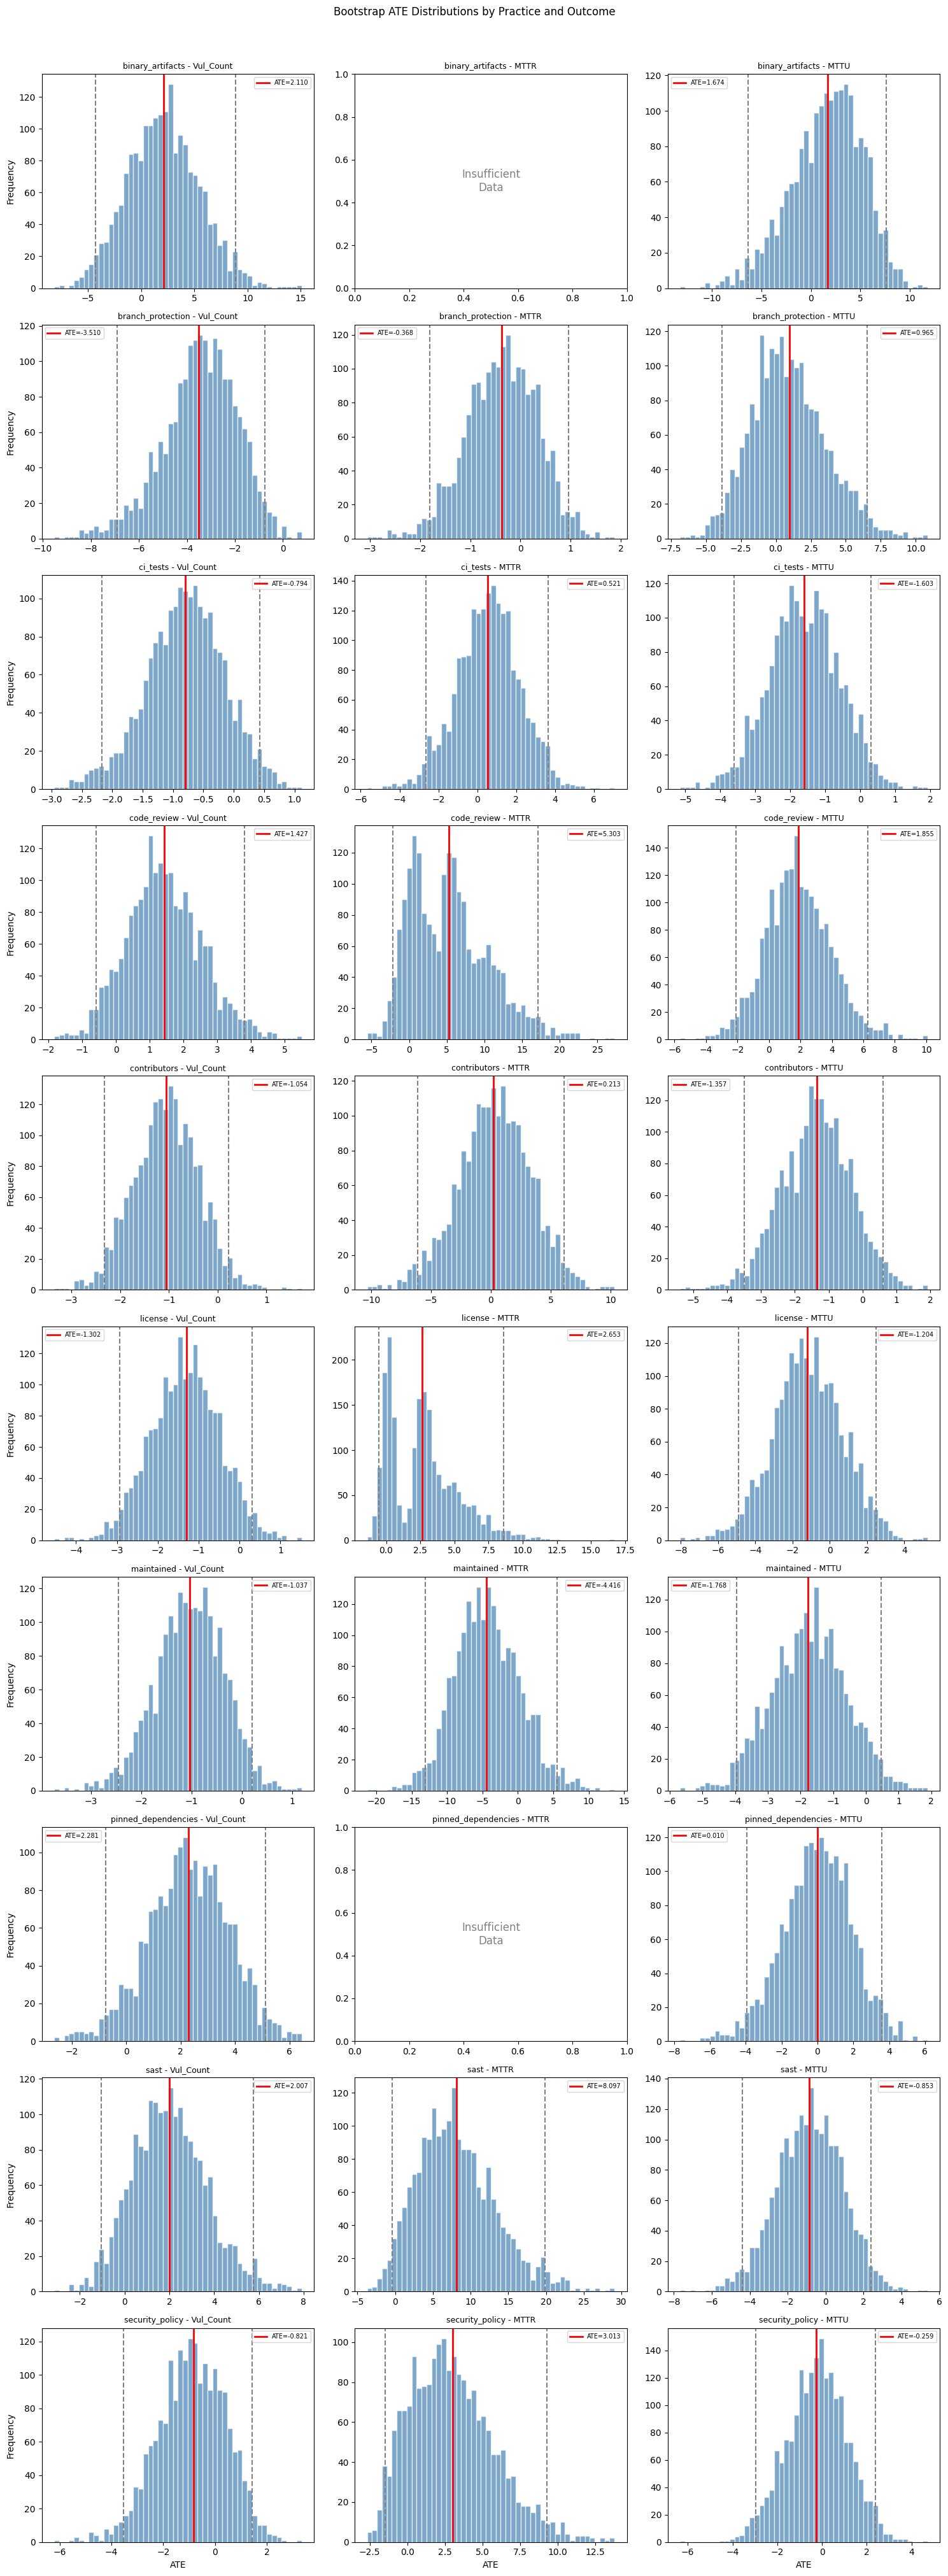

In [66]:
fig, axes = plt.subplots(len(TOP_PRACTICES), 3,
                          figsize=(15, 4 * len(TOP_PRACTICES)),
                          squeeze=False)

for row, practice in enumerate(TOP_PRACTICES):
    result = psm_results[practice]
    for col, outcome_name in enumerate(["Vul_Count", "MTTR", "MTTU"]):
        ax = axes[row, col]
        ate = result["ate_results"].get(outcome_name)

        if ate is None:
            ax.text(0.5, 0.5, "Insufficient\nData", transform=ax.transAxes,
                    ha="center", va="center", fontsize=12, color="gray")
            ax.set_title(f"{practice} - {outcome_name}", fontsize=9)
            continue

        ax.hist(ate["distribution"], bins=50, color="steelblue", alpha=0.7, edgecolor="white")
        ax.axvline(ate["ate"], color="red", linestyle="-", linewidth=2,
                   label=f"ATE={ate['ate']:.3f}")
        ax.axvline(ate["ci_lower"], color="gray", linestyle="--")
        ax.axvline(ate["ci_upper"], color="gray", linestyle="--")
        ax.set_title(f"{practice} - {outcome_name}", fontsize=9)
        ax.legend(fontsize=7)

        if row == len(TOP_PRACTICES) - 1:
            ax.set_xlabel("ATE")
        if col == 0:
            ax.set_ylabel("Frequency")

plt.suptitle("Bootstrap ATE Distributions by Practice and Outcome", y=1.01)
plt.tight_layout()
plt.show()

### Note on Heterogeneity Analysis

The reference paper notes that heterogeneity (segment) analysis could not be performed for individual security practices due to small sample sizes after matching (Section 6.1.3). We confirm this limitation: after balanced sampling and PSM matching for individual practices, further stratification by terciles would yield subgroups too small for reliable inference. We therefore omit this step for RQ2, consistent with the paper's approach.

## Summary

This analysis addressed RQ2 by:

1. **Random Forest Regression**: Modeled each outcome (Vul_Count, MTTR, MTTU) using 11 individual security practices and 6 control variables, following the paper's methodology.
2. **Feature Importance Ranking**: Extracted Gini importance to identify the practices most strongly associated with outcomes.
3. **Propensity Score Matching**: For each top-ranked practice, applied balanced sampling, propensity score estimation, nearest-neighbor matching, and bootstrap ATE to estimate the causal effect of each practice on each outcome.

Key findings are summarized in the ATE heatmap above.